In [1]:
import os
import tarfile
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
def load_housing_data():
	tarball_path = Path("datasets/housing.tgz")
	if not tarball_path.is_file():
		Path("datasets").mkdir(parents=True, exist_ok=True)
		url = "https://github.com/ageron/data/raw/main/housing.tgz"
		urllib.request.urlretrieve(url, tarball_path)
	with tarfile.open(tarball_path) as housing_tarball:
		extract_path = Path("datasets")
		# ensure no path traversal in the archive
		for member in housing_tarball.getmembers():
			member_path = extract_path / member.name
			if os.path.commonpath([
				str(extract_path.resolve()),
				str(member_path.resolve()),
			]) != str(extract_path.resolve()):
				raise Exception("Attempted Path Traversal in Tar File")
		housing_tarball.extractall(
			path=str(extract_path), filter=lambda tarinfo, path: tarinfo
		)
	return pd.read_csv(Path("datasets/housing/housing.csv"))


housing = load_housing_data()

In [3]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


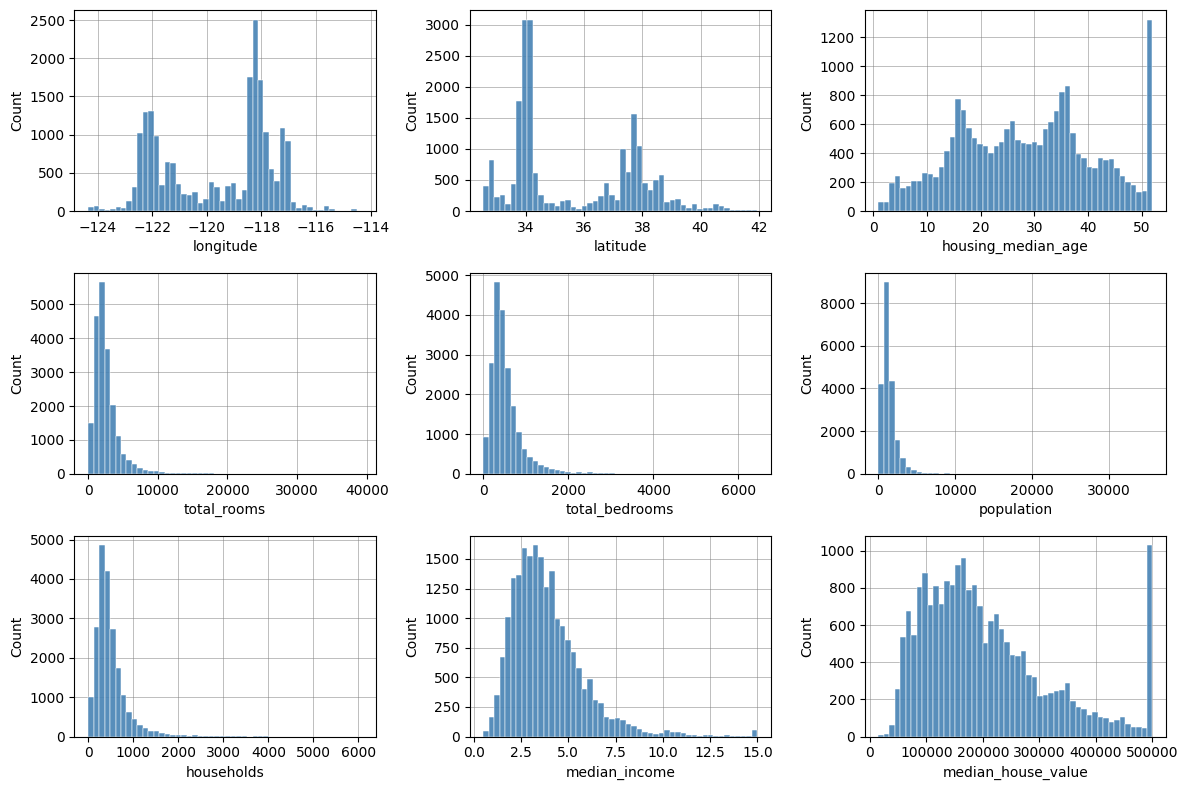

In [7]:
columns = housing.select_dtypes("number")
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(columns):
	sns.histplot(
		data=housing,
		x=col,
		bins=50,
		ax=axes[i],
		color="steelblue",
		edgecolor="white",
		alpha=0.9,
	)

for ax in axes:
	ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [8]:
housing["income_cat"] = pd.cut(
	housing["median_income"],
	bins=[0.0, 1.5, 3.0, 4.5, 6, np.inf],
	labels=[1, 2, 3, 4, 5],
)

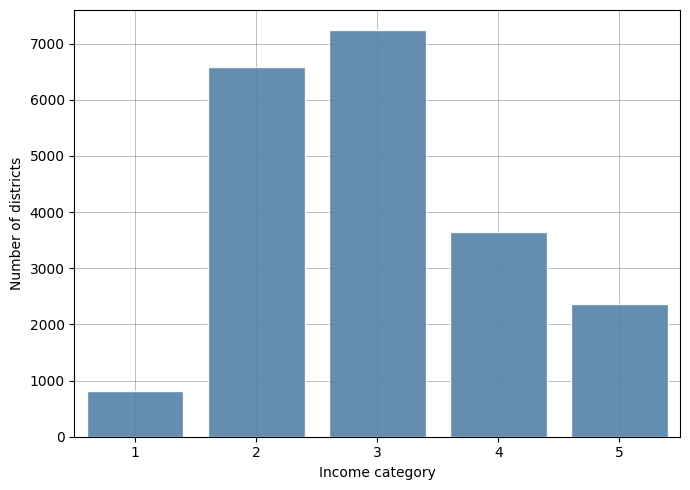

In [9]:
income_cat_sorted = housing["income_cat"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=income_cat_sorted, color="steelblue", edgecolor="white", alpha=0.9)
ax.set(xlabel="Income category", ylabel="Number of districts")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [10]:
# Import StratifiedShuffleSplit for stratified sampling to maintain class proportions in splits
from sklearn.model_selection import StratifiedShuffleSplit

# Initialize splitter with 10 splits, 20% test size, and seed for reproducibility; stratified sampling ensures income_cat distribution is preserved across train/test sets
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
# Loop over splits; split() generates indices stratified by income_cat to avoid sampling bias in imbalanced data
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
	# Extract training set using indices; iloc selects rows by position for subsetting
	strat_train_set_n = housing.iloc[train_index]
	# Extract test set using indices; ensures test set is unseen and representative
	strat_test_set_n = housing.iloc[test_index]
	# Append train-test pair to list; collects multiple splits for cross-validation stability
	strat_splits.append([strat_train_set_n, strat_test_set_n])

In [11]:
strat_train_set, strat_test_set = strat_splits[0]

In [12]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [14]:
for set_ in (strat_train_set, strat_test_set):
	if "income_cat" in set_.columns:
		set_.drop("income_cat", axis=1, inplace=True)

In [15]:
housing = strat_train_set.copy()

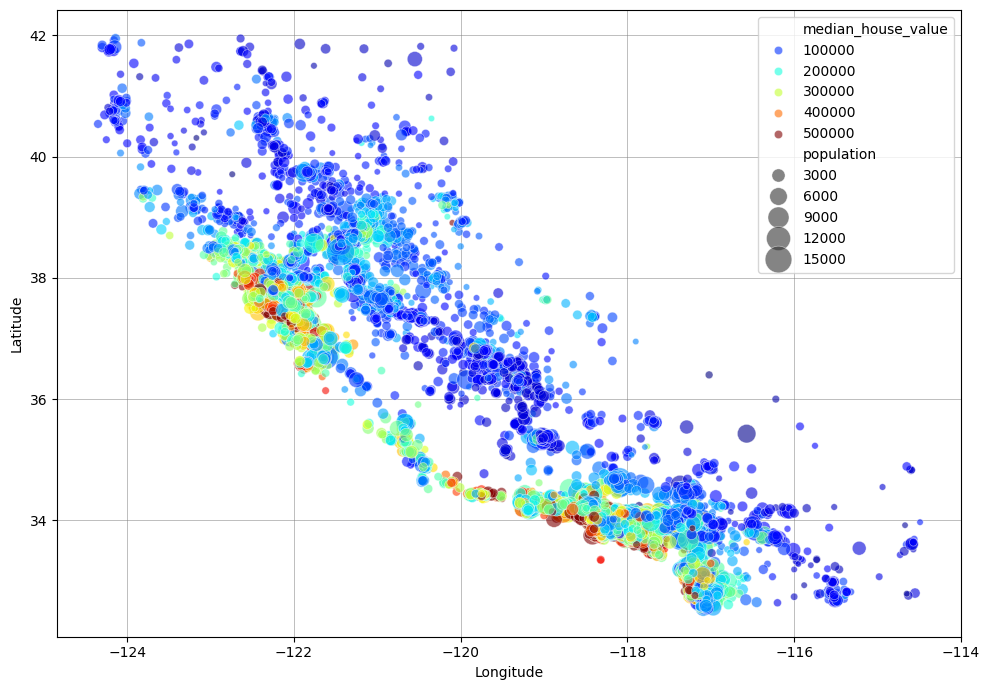

In [16]:
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(
	data=housing,
	x="longitude",
	y="latitude",
	hue="median_house_value",
	size="population",
	palette=mpl.colormaps["jet"],
	sizes=(20, 400),
	alpha=0.6,
	ax=ax,
)
ax.set(xlabel="Longitude", ylabel="Latitude")
ax.grid(True, alpha=0.6, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [17]:
corr_matrix = housing.corr(numeric_only=True)

In [18]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

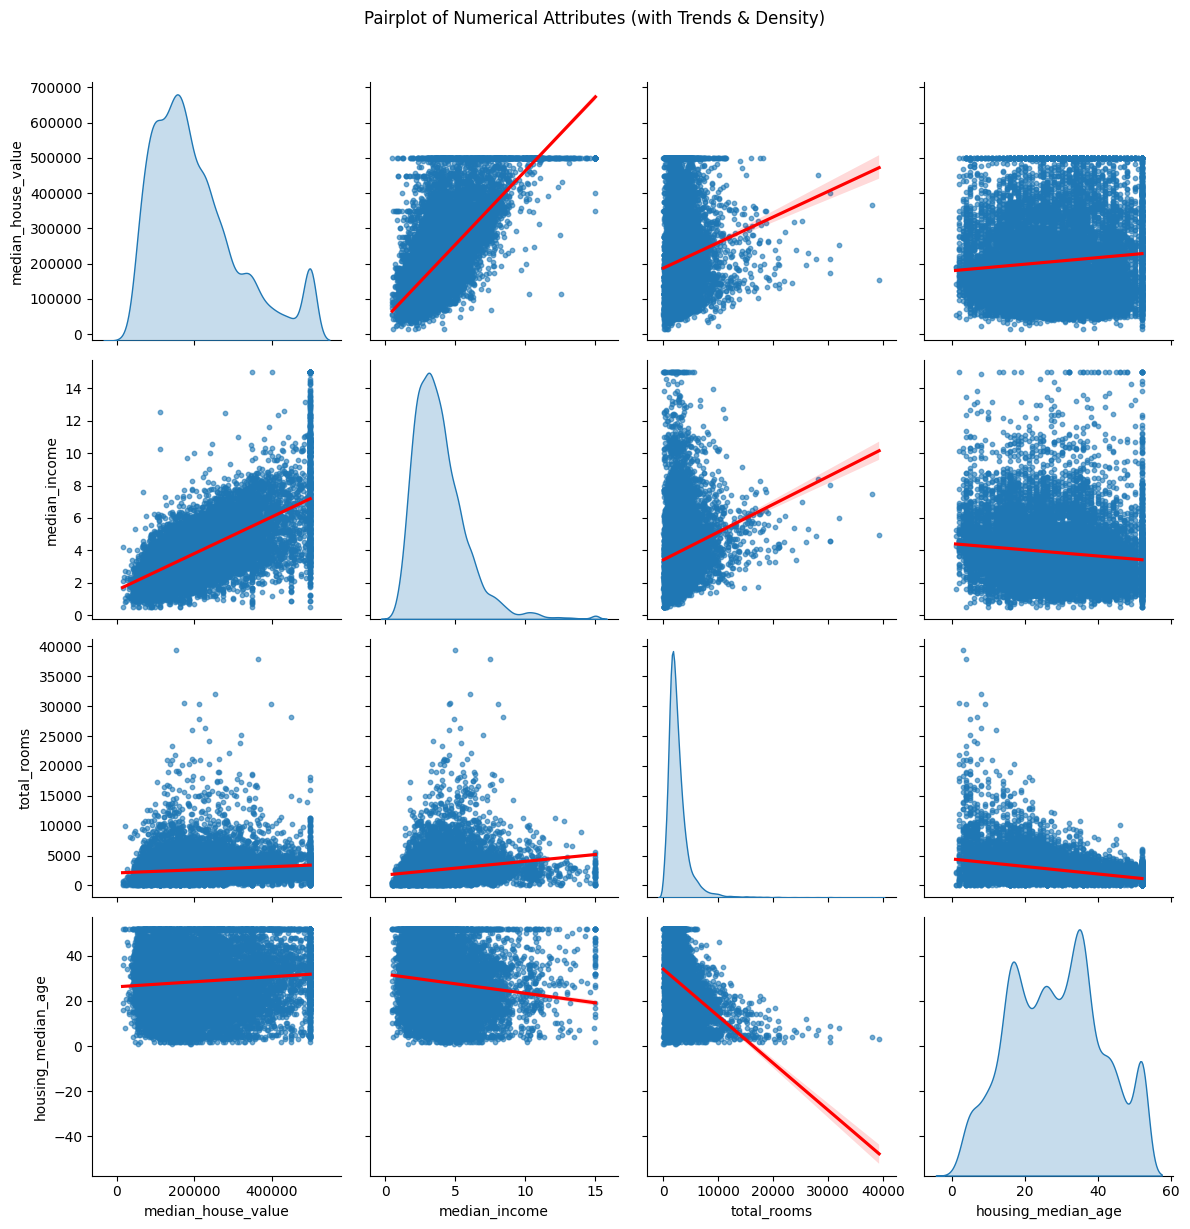

In [19]:
attributes = [
	"median_house_value",
	"median_income",
	"total_rooms",
	"housing_median_age",
]

g = sns.pairplot(
	housing[attributes],
	diag_kind="kde",
	plot_kws={"scatter_kws": {"alpha": 0.6, "s": 10}, "line_kws": {"color": "red"}},
	kind="reg",
	height=3,
	corner=False,
)

g.fig.suptitle("Pairplot of Numerical Attributes (with Trends & Density)", y=1.02)
plt.tight_layout()
plt.show()

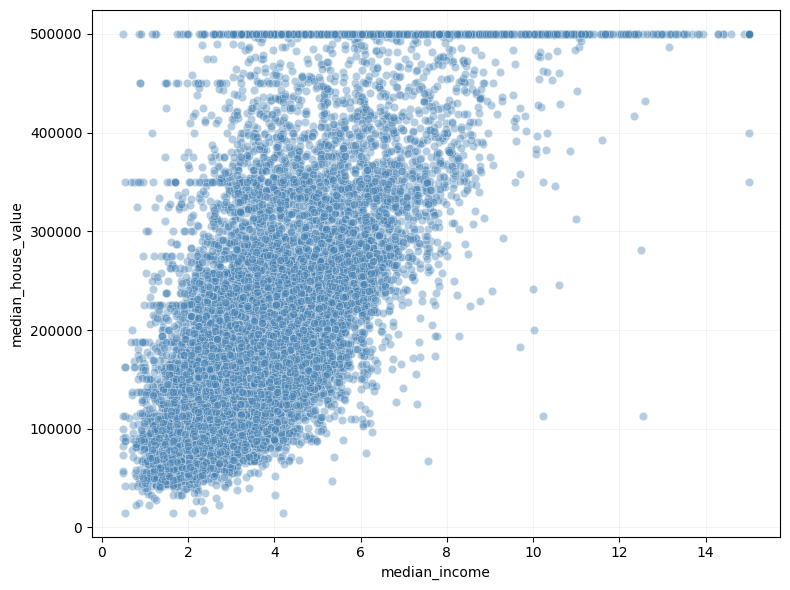

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
	data=housing,
	x="median_income",
	y="median_house_value",
	color="steelblue",
	alpha=0.4,
	ax=ax,
)
ax.grid(True, alpha=0.1, linewidth=0.6, color="grey")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [21]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [22]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

In [23]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing.select_dtypes(include=[np.number])
imputer.fit(housing_num)
X = imputer.transform(housing_num)

housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

In [25]:
housing_cat = housing[["ocean_proximity"]]

In [28]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [27]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [60]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [31]:
# Define df_test_unknown as a DataFrame with similar structure to housing_cat
df_test_unknown = pd.DataFrame(
	{"ocean_proximity": ["<1H OCEAN", "INLAND", "NEAR BAY", "NEAR OCEAN", "ISLAND"]}
)

# Set handle_unknown to "ignore" and transform the data
cat_encoder.handle_unknown = "ignore"
cat_encoder.transform(df_test_unknown)

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0.]])

In [32]:
df_output = pd.DataFrame(
	cat_encoder.transform(housing_cat),
	columns=cat_encoder.get_feature_names_out(),
	index=housing_cat.index,
)
